In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 65.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# 1 FDM

## 1.1 三层不同的设置

Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 4.02 s
Lx=4.00 m, progress: 20.0%
Lx=4.00 m, progress: 40.0%
Lx=4.00 m, progress: 60.0%
Lx=4.00 m, progress: 80.0%
Lx=4.00 m finished in 2.24 s
Lx=3.00 m, progress: 20.0%
Lx=3.00 m, progress: 40.0%
Lx=3.00 m, progress: 60.0%
Lx=3.00 m, progress: 80.0%
Lx=3.00 m finished in 1.76 s


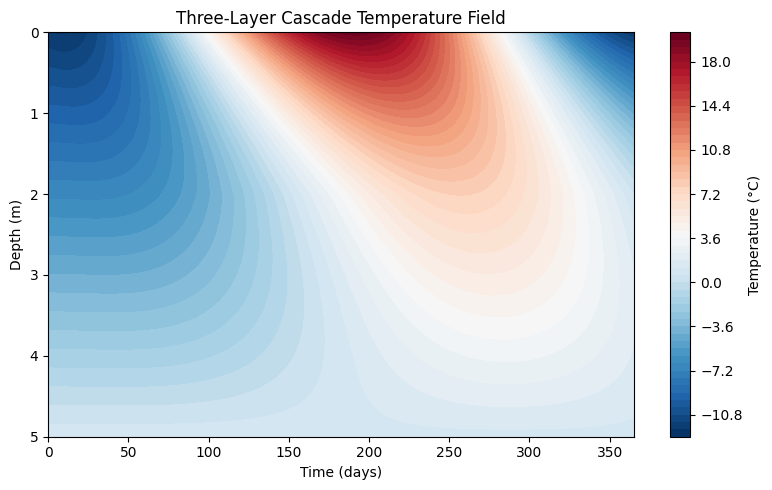

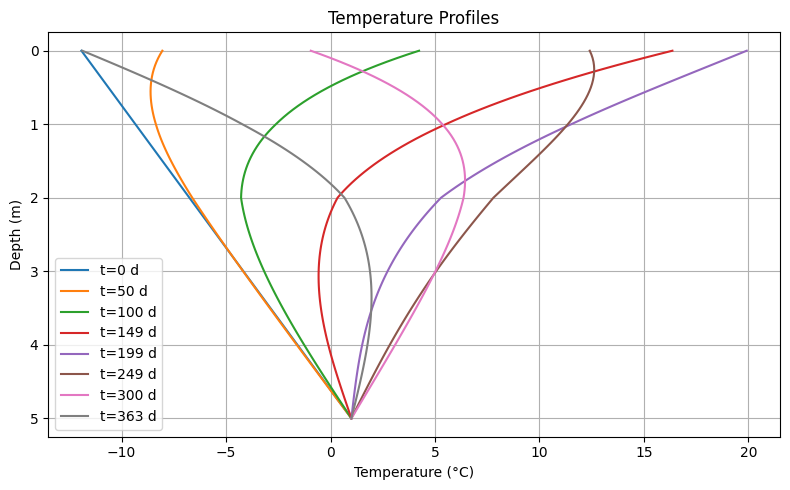

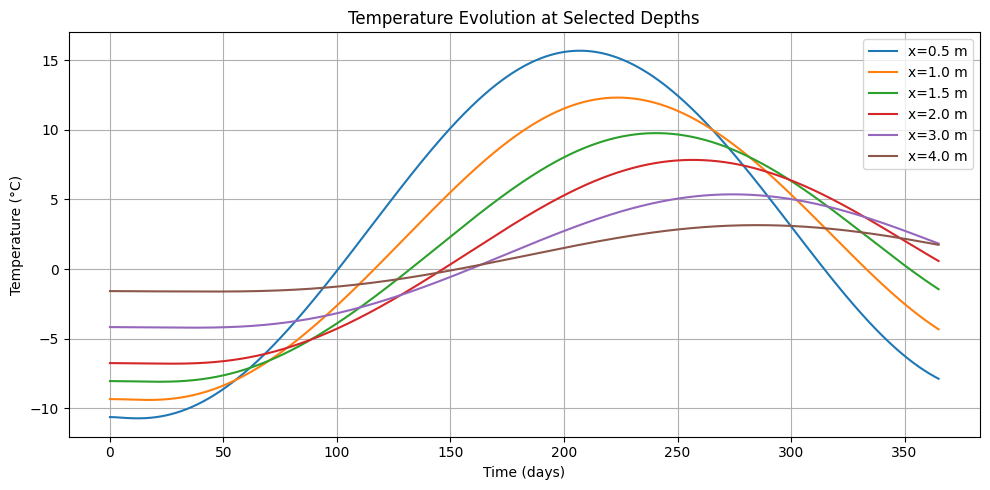

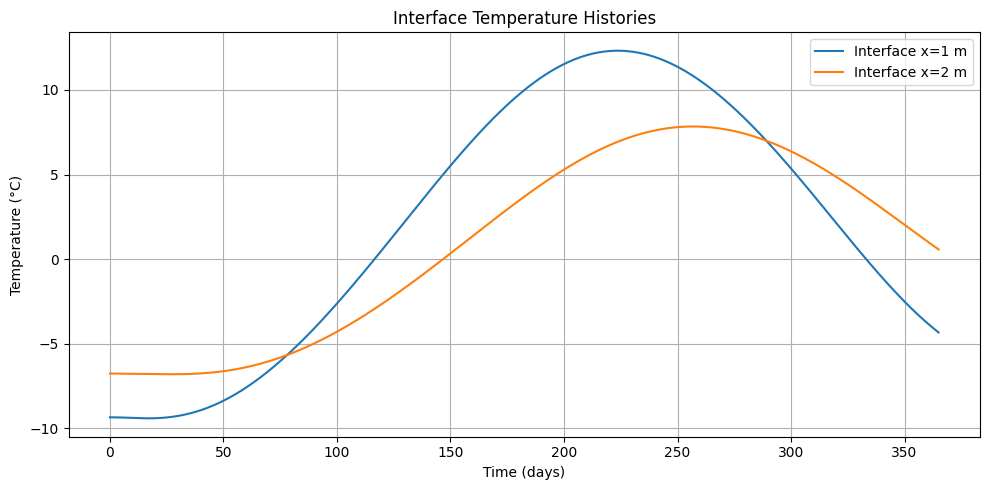

Final surface temperature = -11.926392173059488
Final bottom temperature  = 1.0
Three-layer FDM result saved to fdm_three_layer_cascade_result.npz


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # Physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        # Grid
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def theta_unfrozen(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    def initialize(self, Nx=101, Nt=4000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)

    def solve_implicit_custom_bc(self, top_bc_func, bottom_bc_func, init_profile, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        self.T_field[:, 0] = init_profile.copy()
        T_old = self.T_field[:, 0].copy()

        start = time.time()

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            A[0, 0] = 1.0
            b[0] = top_bc_func(t_new)

            A[-1, -1] = 1.0
            b[-1] = bottom_bc_func(t_new)

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p
                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 5) == 0:
                print(f"Lx={self.Lx:.2f} m, progress: {100.0 * n / self.Nt:.1f}%")

        if verbose:
            print(f"Lx={self.Lx:.2f} m finished in {time.time() - start:.2f} s")

        return self.T_field

    def solve_original_single(self, verbose=True):
        init_profile = self.initial_temperature_profile(self.x)
        return self.solve_implicit_custom_bc(
            top_bc_func=self.boundary_temperature,
            bottom_bc_func=lambda t: 1.0,
            init_profile=init_profile,
            verbose=verbose
        )


def restricted_initial_profile_from_linear_bc(x_sub_local, x_offset, full_depth=5.0):
    """
    Initial condition built from the original global linear initial condition:
    T(x,0) = T_surface(0) + (T_bottom - T_surface(0)) * x / full_depth
    """
    T_surface0 = 4.03 + 16.11 * np.sin(2.0 * np.pi * 0.0 / 365.0 - 1.709)
    T_bottom = 1.0
    x_actual = x_sub_local + x_offset
    return T_surface0 + (T_bottom - T_surface0) * x_actual / full_depth


def run_three_layer_cascade():
    # Shared parameters
    common = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'theta_r': 0.10,
        'T_f': -0.3,
    }

    # Layer 1
    params1 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.0e-6 * 8.64e4,
        'eta': 0.4,
        'k': 0.1
    }

    # Layer 2
    params2 = {
        **common,
        'C_f': 2.0,
        'lambda_f': 1.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    # Layer 3
    params3 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    Nt = 4000
    T_total = 365.0

    # =====================================================
    # Step 1: 0-5 m using layer-1 parameters
    # =====================================================
    step1 = FreezingSoilFDM_LogisticAHC(params1)
    step1.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)

    init1 = step1.initial_temperature_profile(step1.x)

    T_step1 = step1.solve_implicit_custom_bc(
        top_bc_func=step1.boundary_temperature,
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init1,
        verbose=True
    )

    x_full = step1.x
    t = step1.t

    idx_1m = np.argmin(np.abs(step1.x - 1.0))
    T12 = T_step1[idx_1m, :]

    # =====================================================
    # Step 2: 1-5 m using layer-2 parameters
    # =====================================================
    step2 = FreezingSoilFDM_LogisticAHC(params2)
    step2.initialize(Nx=81, Nt=Nt, Lx=4.0, T_total=T_total)

    init2 = restricted_initial_profile_from_linear_bc(
        x_sub_local=step2.x,
        x_offset=1.0,
        full_depth=5.0
    )

    T_step2 = step2.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T12),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init2,
        verbose=True
    )

    idx_local_1m = np.argmin(np.abs(step2.x - 1.0))
    T23 = T_step2[idx_local_1m, :]

    # =====================================================
    # Step 3: 2-5 m using layer-3 parameters
    # =====================================================
    step3 = FreezingSoilFDM_LogisticAHC(params3)
    step3.initialize(Nx=61, Nt=Nt, Lx=3.0, T_total=T_total)

    init3 = restricted_initial_profile_from_linear_bc(
        x_sub_local=step3.x,
        x_offset=2.0,
        full_depth=5.0
    )

    T_step3 = step3.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T23),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init3,
        verbose=True
    )

    # =====================================================
    # Assemble final three-layer field
    # 0-1 m from step1
    # 1-2 m from step2
    # 2-5 m from step3
    # =====================================================
    T_cascade = np.zeros_like(T_step1)

    for i, xx in enumerate(x_full):
        if xx < 1.0:
            idx = np.argmin(np.abs(step1.x - xx))
            T_cascade[i, :] = T_step1[idx, :]
        elif xx < 2.0:
            idx = np.argmin(np.abs(step2.x - (xx - 1.0)))
            T_cascade[i, :] = T_step2[idx, :]
        else:
            idx = np.argmin(np.abs(step3.x - (xx - 2.0)))
            T_cascade[i, :] = T_step3[idx, :]

    # =====================================================
    # Plot 1: full temperature field
    # =====================================================
    plt.figure(figsize=(8, 5))
    im = plt.contourf(t, x_full, T_cascade, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("Three-Layer Cascade Temperature Field")
    plt.colorbar(im, label="Temperature (°C)")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: temperature profiles at selected times
    # =====================================================
    plt.figure(figsize=(8, 5))
    times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx_t = np.argmin(np.abs(t - tt))
        plt.plot(T_cascade[:, idx_t], x_full, label=f"t={int(t[idx_t])} d")
    plt.gca().invert_yaxis()
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Depth (m)")
    plt.title("Temperature Profiles")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 3: temperature evolution at selected depths
    # =====================================================
    plt.figure(figsize=(10, 5))
    depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x_full - dd))
        plt.plot(t, T_cascade[idx, :], label=f"x={x_full[idx]:.1f} m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature Evolution at Selected Depths")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 4: layer interface temperatures
    # =====================================================
    plt.figure(figsize=(10, 5))
    plt.plot(t, T12, label="Interface x=1 m")
    plt.plot(t, T23, label="Interface x=2 m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Interface Temperature Histories")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Final surface temperature =", T_cascade[0, -1])
    print("Final bottom temperature  =", T_cascade[-1, -1])

    np.savez(
        "fdm_three_layer_cascade_result.npz",
        x=x_full,
        t=t,
        T_cascade=T_cascade,
        T12=T12,
        T23=T23
    )

    print("Three-layer FDM result saved to fdm_three_layer_cascade_result.npz")

    return {
        "x": x_full,
        "t": t,
        "T_cascade": T_cascade,
        "T12": T12,
        "T23": T23,
        "step1": step1,
        "step2": step2,
        "step3": step3
    }

if __name__ == "__main__":
    results = run_three_layer_cascade()

# 2. PINNs Inversion Model
3-layer different setup

## 2.1 First layer inversion

Random initial eta      = 0.36988963
Random initial lambda_f = 0.21953006
Random initial k        = 0.11391964
Random initial C_f      = 1.69471214
Observation points loaded: 16000
Boundary data loaded from x=0 m and x=1 m.
True eta value         = 0.4
True lambda_f value    = 0.17279999999999998
True k value           = 0.1
True C_f value         = 1.6
Initial eta guess      = 0.36988961696624756
Initial lambda_f guess = 0.21953006088733673
Initial k guess        = 0.11391963064670563
Initial C_f guess      = 1.6947121620178223
Epoch      1 | Total=3.022017e+04 | PDE=5.140227e-07 | IC=1.152849e+02 | BC=2.237380e+02 | DATA=9.458993e+01 | eta=0.369833 | lambda_f=0.219535 | k=0.113920 | C_f=1.694712 | time=0.8s
Epoch    500 | Total=1.329883e+02 | PDE=4.388224e-01 | IC=1.108300e-01 | BC=1.291729e+00 | DATA=1.220439e-01 | eta=0.363180 | lambda_f=0.216543 | k=0.113920 | C_f=1.694712 | time=11.2s
Epoch   1000 | Total=1.291286e+01 | PDE=5.264809e-02 | IC=2.753436e-02 | BC=9.896860e-02 | DATA=

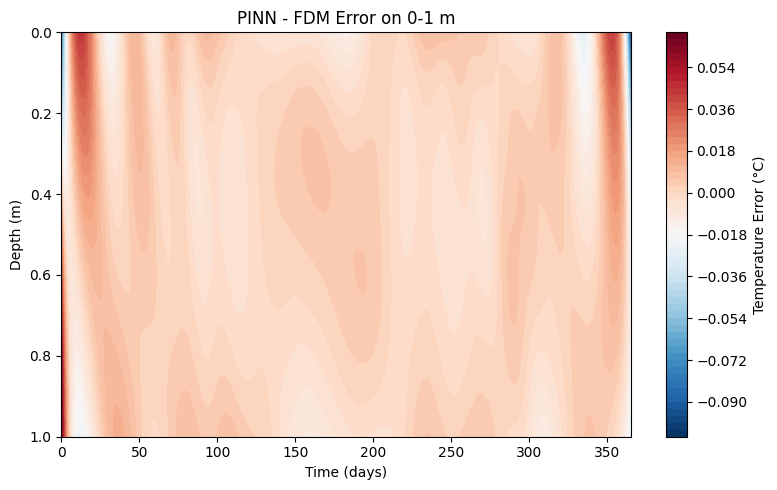


Final estimated parameters (0-1 m inversion):
eta_true        = 0.4
eta_inv         = 0.3722915053367615
lambda_f_true   = 0.17279999999999998
lambda_f_inv    = 0.1716097891330719
k_true          = 0.1
k_inv           = 0.11391963064670563
C_f_true        = 1.6
C_f_inv         = 1.6947121620178223


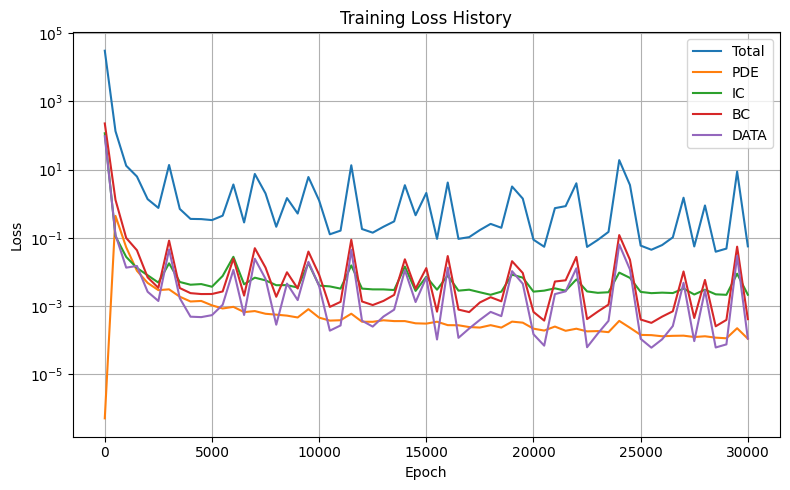

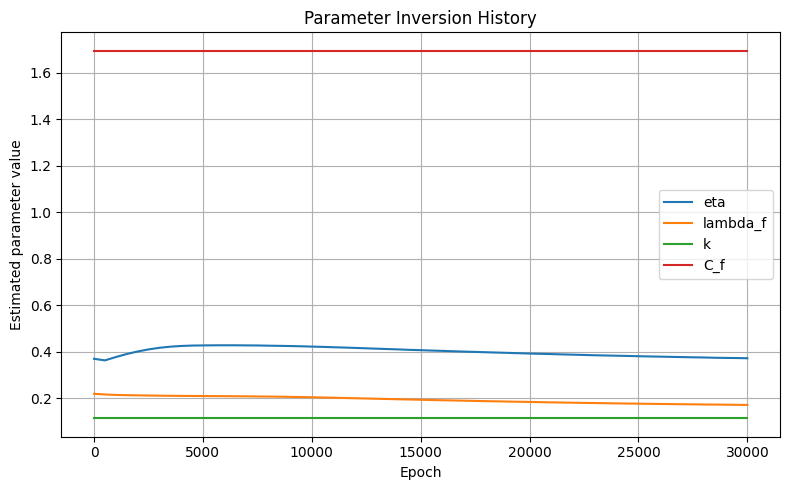

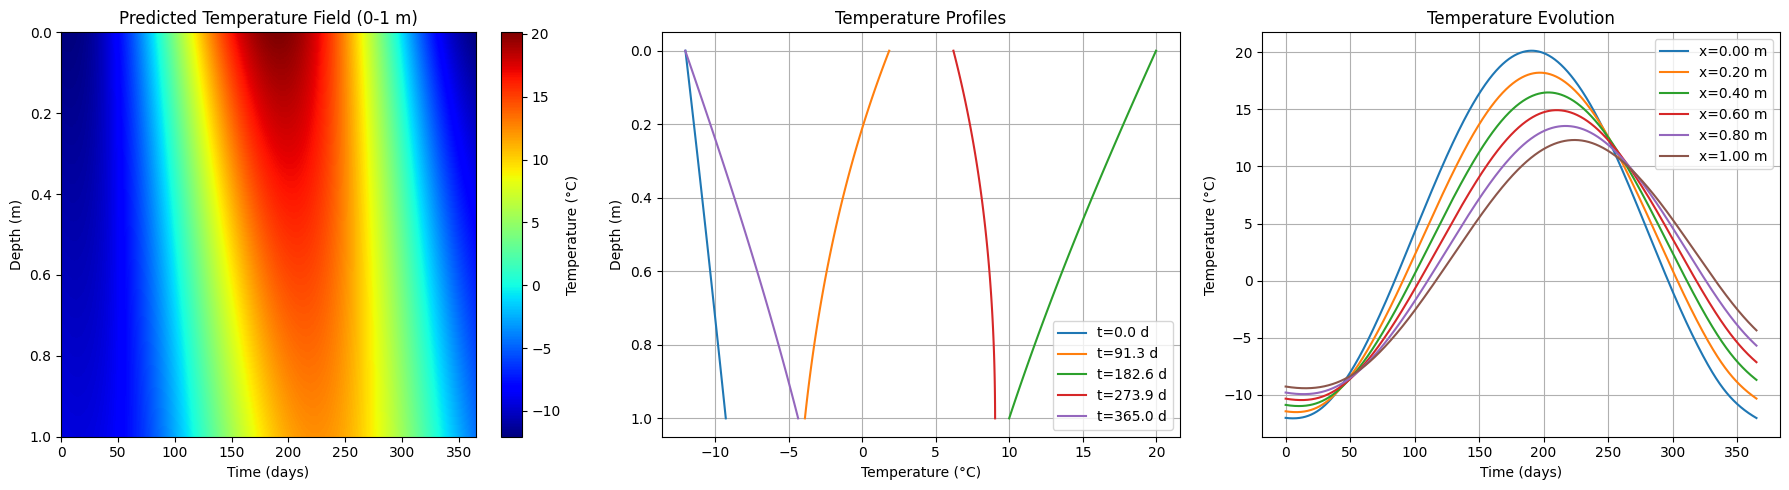

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# Inverse PINN model for 0-1 m inversion
# =========================================================
class FreezingSoilInversePINN:
    def __init__(self, params, device=None):
        # fixed physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']

        self.theta_r = params['theta_r']
        self.T_f = params['T_f']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        self.Lx = None
        self.T_total = None
        self.x_scale = None
        self.t_scale = None

        # true values of inversion parameters
        self.eta_true = params['eta_true']
        self.lambda_f_true = params['lambda_f_true']
        self.k_true = params['k_true']
        self.C_f_true = params['C_f_true']

        # inversion switches
        self.invert_eta = params.get("invert_eta", True)
        self.invert_lambda_f = params.get("invert_lambda_f", True)
        self.invert_k = params.get("invert_k", False)
        self.invert_C_f = params.get("invert_C_f", False)

        # bounded ranges
        self.eta_min = 0.7 * self.eta_true
        self.eta_max = 1.3 * self.eta_true

        self.lambda_f_min = 0.7 * self.lambda_f_true
        self.lambda_f_max = 1.3 * self.lambda_f_true

        self.k_min = 0.7 * self.k_true
        self.k_max = 1.3 * self.k_true

        self.C_f_min = 0.7 * self.C_f_true
        self.C_f_max = 1.3 * self.C_f_true

        # random initialization
        eta_init = np.random.uniform(self.eta_min, self.eta_max)
        lambda_f_init = np.random.uniform(self.lambda_f_min, self.lambda_f_max)
        k_init = np.random.uniform(self.k_min, self.k_max)
        C_f_init = np.random.uniform(self.C_f_min, self.C_f_max)

        print(f"Random initial eta      = {eta_init:.8f}")
        print(f"Random initial lambda_f = {lambda_f_init:.8f}")
        print(f"Random initial k        = {k_init:.8f}")
        print(f"Random initial C_f      = {C_f_init:.8f}")

        def inverse_bounded_sigmoid(p_init, p_min, p_max):
            z = (p_init - p_min) / (p_max - p_min)
            z = np.clip(z, 1e-6, 1.0 - 1e-6)
            return np.log(z / (1.0 - z))

        self.eta_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(eta_init, self.eta_min, self.eta_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_eta
        )
        self.lambda_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(lambda_f_init, self.lambda_f_min, self.lambda_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_lambda_f
        )
        self.k_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(k_init, self.k_min, self.k_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_k
        )
        self.C_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(C_f_init, self.C_f_min, self.C_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_C_f
        )

        self.loss_history = []

        self.x_data = None
        self.t_data = None
        self.T_data = None

        self.t_bc = None
        self.T_left_bc = None
        self.T_right_bc = None

    @property
    def eta(self):
        return self.eta_min + (self.eta_max - self.eta_min) * torch.sigmoid(self.eta_raw)

    @property
    def lambda_f(self):
        return self.lambda_f_min + (self.lambda_f_max - self.lambda_f_min) * torch.sigmoid(self.lambda_f_raw)

    @property
    def k(self):
        return self.k_min + (self.k_max - self.k_min) * torch.sigmoid(self.k_raw)

    @property
    def C_f(self):
        return self.C_f_min + (self.C_f_max - self.C_f_min) * torch.sigmoid(self.C_f_raw)

    # =========================================================
    # Initial condition on 0-1 m
    # =========================================================
    def initial_temperature_profile_np(self, x):
        # Restriction of the original global initial field on [0,1]
        T_surface0 = 4.03 + 16.11 * np.sin(2.0 * np.pi * 0.0 / 365.0 - 1.709)
        T_bottom = 1.0
        return T_surface0 + (T_bottom - T_surface0) * x / 5.0

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def add_boundary_data(self, t_bc, T_left_bc, T_right_bc):
        self.t_bc = np.asarray(t_bc).reshape(-1)
        self.T_left_bc = np.asarray(T_left_bc).reshape(-1)
        self.T_right_bc = np.asarray(T_right_bc).reshape(-1)

    def sample_boundary(self, N_b):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set. Call add_boundary_data() first.")

        t = np.random.rand(N_b, 1) * self.T_total
        t_flat = t.reshape(-1)

        x_left = np.zeros((N_b, 1))
        T_left = np.interp(t_flat, self.t_bc, self.T_left_bc).reshape(-1, 1)

        x_right = np.ones((N_b, 1)) * self.Lx
        T_right = np.interp(t_flat, self.t_bc, self.T_right_bc).reshape(-1, 1)

        return (
            torch.tensor(x_left, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T_left, dtype=torch.float32, device=self.device),
            torch.tensor(x_right, dtype=torch.float32, device=self.device),
            torch.tensor(T_right, dtype=torch.float32, device=self.device),
        )

    # =========================================================
    # Observation data
    # =========================================================
    def add_temperature_observations(self, x_obs, t_obs, T_obs):
        self.x_data = torch.tensor(x_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.t_data = torch.tensor(t_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.T_data = torch.tensor(T_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)

    # =========================================================
    # Loss function
    # =========================================================
    def loss_function(self, N_f, N_i, N_b, w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0):
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        x_i, t_i, T_i = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i) ** 2)

        x_left, t_b, T_left, x_right, T_right = self.sample_boundary(N_b)
        T_left_pred = self.net_T(x_left, t_b)
        T_right_pred = self.net_T(x_right, t_b)

        loss_bc_left = torch.mean((T_left_pred - T_left) ** 2)
        loss_bc_right = torch.mean((T_right_pred - T_right) ** 2)
        loss_bc = loss_bc_left + loss_bc_right

        if self.x_data is not None:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)
        else:
            loss_data = torch.tensor(0.0, device=self.device)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        return total_loss, loss_pde, loss_ic, loss_bc, loss_data

    # =========================================================
    # Training
    # =========================================================
    def train(
        self,
        Lx,
        T_total,
        epochs_adam=30000,
        lr=1e-3,
        N_f=4000,
        N_i=500,
        N_b=500,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total

        params_to_optimize = list(self.model.parameters())
        if self.invert_eta:
            params_to_optimize.append(self.eta_raw)
        if self.invert_lambda_f:
            params_to_optimize.append(self.lambda_f_raw)
        if self.invert_k:
            params_to_optimize.append(self.k_raw)
        if self.invert_C_f:
            params_to_optimize.append(self.C_f_raw)

        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        start_time = time.time()

        for epoch in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                eta_val = self.eta.item()
                lambda_f_val = self.lambda_f.item()
                k_val = self.k.item()
                C_f_val = self.C_f.item()

                self.loss_history.append([
                    epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    eta_val,
                    lambda_f_val,
                    k_val,
                    C_f_val
                ])

                elapsed = time.time() - start_time
                print(
                    f"Epoch {epoch:6d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"PDE={loss_pde.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"eta={eta_val:.6f} | "
                    f"lambda_f={lambda_f_val:.6f} | "
                    f"k={k_val:.6f} | "
                    f"C_f={C_f_val:.6f} | "
                    f"time={elapsed:.1f}s"
                )

        if use_lbfgs:
            print("\nStarting L-BFGS optimization ...")

            optimizer_lbfgs = torch.optim.LBFGS(
                params_to_optimize,
                lr=1.0,
                max_iter=1000,
                max_eval=1200,
                history_size=50,
                tolerance_grad=1e-9,
                tolerance_change=1e-11,
                line_search_fn="strong_wolfe"
            )

            iteration_counter = [0]

            def closure():
                optimizer_lbfgs.zero_grad()

                total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )

                total_loss.backward()

                iteration_counter[0] += 1
                if iteration_counter[0] % 50 == 0:
                    eta_val = self.eta.item()
                    lambda_f_val = self.lambda_f.item()
                    k_val = self.k.item()
                    C_f_val = self.C_f.item()

                    self.loss_history.append([
                        epochs_adam + iteration_counter[0],
                        total_loss.item(),
                        loss_pde.item(),
                        loss_ic.item(),
                        loss_bc.item(),
                        loss_data.item(),
                        eta_val,
                        lambda_f_val,
                        k_val,
                        C_f_val
                    ])

                    print(
                        f"[LBFGS {iteration_counter[0]:5d}] "
                        f"Total={total_loss.item():.6e} | "
                        f"PDE={loss_pde.item():.6e} | "
                        f"IC={loss_ic.item():.6e} | "
                        f"BC={loss_bc.item():.6e} | "
                        f"DATA={loss_data.item():.6e} | "
                        f"eta={eta_val:.6f} | "
                        f"lambda_f={lambda_f_val:.6f} | "
                        f"k={k_val:.6f} | "
                        f"C_f={C_f_val:.6f}"
                    )

                return total_loss

            optimizer_lbfgs.step(closure)

        print("\nTraining finished.")
        print(f"Estimated eta      = {self.eta.item():.8f}")
        print(f"Estimated lambda_f = {self.lambda_f.item():.8f}")
        print(f"Estimated k        = {self.k.item():.8f}")
        print(f"Estimated C_f      = {self.C_f.item():.8f}")

    # =========================================================
    # Prediction
    # =========================================================
    def predict_field(self, Nx=101, Nt=1500):
        x = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        XX, TT = np.meshgrid(x, t, indexing='ij')

        x_in = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=self.device)
        t_in = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            T_pred = self.net_T(x_in, t_in).cpu().numpy().reshape(Nx, Nt)

        return x, t, T_pred

    # =========================================================
    # Plot
    # =========================================================
    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(8, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hist[:, 0], hist[:, 6], label='eta')
        plt.plot(hist[:, 0], hist[:, 7], label='lambda_f')
        plt.plot(hist[:, 0], hist[:, 8], label='k')
        plt.plot(hist[:, 0], hist[:, 9], label='C_f')
        plt.xlabel("Epoch")
        plt.ylabel("Estimated parameter value")
        plt.title("Parameter Inversion History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_results(self, Nx=101, Nt=1500):
        x, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].imshow(
            T_field,
            extent=[t.min(), t.max(), x.max(), x.min()],
            aspect='auto',
            cmap='jet'
        )
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Predicted Temperature Field (0-1 m)')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        t_indices = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]
        for idx in t_indices:
            axes[1].plot(T_field[:, idx], x, label=f't={t[idx]:.1f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Helper: build 0-1 m inversion data from three-layer FDM file
# =========================================================
def load_inverse_data_from_three_layer_fdm(npz_file):
    data = np.load(npz_file)

    x_cascade = data["x"]
    t_cascade = data["t"]
    T_cascade = data["T_cascade"]

    idx_left = np.argmin(np.abs(x_cascade - 0.0))
    idx_right = np.argmin(np.abs(x_cascade - 1.0))

    T_left_bc = T_cascade[idx_left, :]
    T_right_bc = T_cascade[idx_right, :]

    internal_depths = [0.2, 0.4, 0.6, 0.8]

    x_obs_list = []
    t_obs_list = []
    T_obs_list = []

    for depth in internal_depths:
        idx = np.argmin(np.abs(x_cascade - depth))
        x_val = x_cascade[idx]

        for j, tt in enumerate(t_cascade):
            x_obs_list.append(x_val)
            t_obs_list.append(tt)
            T_obs_list.append(T_cascade[idx, j])

    x_obs = np.array(x_obs_list).reshape(-1, 1)
    t_obs = np.array(t_obs_list).reshape(-1, 1)
    T_obs = np.array(T_obs_list).reshape(-1, 1)

    return x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs, t_obs, T_obs


# =========================================================
# Compare prediction against FDM on 0-1 m
# =========================================================
def compare_with_fdm_0_1m(x_pred, t_pred, T_pred, x_cascade, t_cascade, T_cascade):
    mask = x_cascade <= 1.0 + 1e-12
    x_ref = x_cascade[mask]
    T_ref = T_cascade[mask, :]

    # interpolate prediction to reference grid if needed
    if not (len(x_pred) == len(x_ref) and np.allclose(x_pred, x_ref) and
            len(t_pred) == len(t_cascade) and np.allclose(t_pred, t_cascade)):
        T_tmp = np.zeros((T_pred.shape[0], len(t_cascade)))
        for i in range(T_pred.shape[0]):
            T_tmp[i, :] = np.interp(t_cascade, t_pred, T_pred[i, :])

        T_pred_interp = np.zeros((len(x_ref), len(t_cascade)))
        for j in range(len(t_cascade)):
            T_pred_interp[:, j] = np.interp(x_ref, x_pred, T_tmp[:, j])
    else:
        T_pred_interp = T_pred

    error = T_pred_interp - T_ref
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    max_abs = np.max(np.abs(error))

    print("\n===== 0-1 m inversion vs FDM =====")
    print(f"MAE      = {mae:.6e}")
    print(f"RMSE     = {rmse:.6e}")
    print(f"Max |err|= {max_abs:.6e}")

    plt.figure(figsize=(8, 5))
    im = plt.contourf(t_cascade, x_ref, error, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("PINN - FDM Error on 0-1 m")
    plt.colorbar(im, label="Temperature Error (°C)")
    plt.tight_layout()
    plt.show()

    return mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp


# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    set_random_seed(42)

    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,

        # true values for layer 1
        'eta_true': 0.40,
        'lambda_f_true': 2.000e-6 * 8.64e4,
        'k_true': 0.10,
        'C_f_true': 1.60,

        'theta_r': 0.10,
        'T_f': -0.3,

        # recommend starting with 2-parameter inversion
        'invert_eta': True,
        'invert_lambda_f': True,
        'invert_k': False,
        'invert_C_f': False
    }

    pinn = FreezingSoilInversePINN(params)

    x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs, t_obs, T_obs = \
        load_inverse_data_from_three_layer_fdm("fdm_three_layer_cascade_result.npz")

    pinn.add_boundary_data(t_cascade, T_left_bc, T_right_bc)
    pinn.add_temperature_observations(x_obs, t_obs, T_obs)

    print("Observation points loaded:", len(T_obs))
    print("Boundary data loaded from x=0 m and x=1 m.")
    print("True eta value         =", params['eta_true'])
    print("True lambda_f value    =", params['lambda_f_true'])
    print("True k value           =", params['k_true'])
    print("True C_f value         =", params['C_f_true'])
    print("Initial eta guess      =", pinn.eta.item())
    print("Initial lambda_f guess =", pinn.lambda_f.item())
    print("Initial k guess        =", pinn.k.item())
    print("Initial C_f guess      =", pinn.C_f.item())

    pinn.train(
        Lx=1.0,
        T_total=365.0,
        epochs_adam=30000,
        lr=1e-3,
        N_f=4000,
        N_i=500,
        N_b=500,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    )

    x_pinn, t_pinn, T_field_pinn = pinn.predict_field(Nx=101, Nt=1500)

    mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp = compare_with_fdm_0_1m(
        x_pinn, t_pinn, T_field_pinn, x_cascade, t_cascade, T_cascade
    )

    np.savez(
        "inverse_pinn_0_1m_result.npz",
        x_pinn=x_pinn,
        t_pinn=t_pinn,
        T_field_pinn=T_field_pinn,
        eta_inv=pinn.eta.item(),
        lambda_f_inv=pinn.lambda_f.item(),
        k_inv=pinn.k.item(),
        C_f_inv=pinn.C_f.item(),
        mae=mae,
        rmse=rmse,
        max_abs=max_abs
    )

    np.savetxt(
        "inverse_pinn_0_1m_loss_history.csv",
        np.array(pinn.loss_history),
        delimiter=",",
        header="epoch,total_loss,pde_loss,ic_loss,bc_loss,data_loss,eta,lambda_f,k,C_f",
        comments=""
    )

    print("\nFinal estimated parameters (0-1 m inversion):")
    print("eta_true        =", params['eta_true'])
    print("eta_inv         =", pinn.eta.item())
    print("lambda_f_true   =", params['lambda_f_true'])
    print("lambda_f_inv    =", pinn.lambda_f.item())
    print("k_true          =", params['k_true'])
    print("k_inv           =", pinn.k.item())
    print("C_f_true        =", params['C_f_true'])
    print("C_f_inv         =", pinn.C_f.item())

    pinn.plot_loss()
    pinn.plot_results(Nx=101, Nt=1500)

## 2.2 Second year inversion 1-2m

Random initial eta      = 0.27741722
Random initial lambda_f = 0.16464754
Random initial k        = 0.11391964
Random initial C_f      = 2.11839018
Observation points loaded: 16000
Boundary data loaded from x=1 m and x=2 m.
True eta value         = 0.3
True lambda_f value    = 0.1296
True k value           = 0.1
True C_f value         = 2.0
Initial eta guess      = 0.27741721272468567
Initial lambda_f guess = 0.16464754939079285
Initial k guess        = 0.11391963064670563
Initial C_f guess      = 2.1183900833129883
Epoch      1 | Total=1.351848e+04 | PDE=4.056598e-07 | IC=6.657571e+01 | BC=9.491148e+01 | DATA=4.353167e+01 | eta=0.277375 | lambda_f=0.164651 | k=0.113908 | C_f=2.118102 | time=0.0s
Epoch    500 | Total=1.558659e+01 | PDE=6.871954e-02 | IC=1.052965e-02 | BC=1.296262e-01 | DATA=1.111397e-02 | eta=0.266353 | lambda_f=0.163374 | k=0.109225 | C_f=1.994282 | time=12.0s
Epoch   1000 | Total=2.123584e+00 | PDE=8.305523e-03 | IC=6.944026e-04 | BC=1.551883e-02 | DATA=2.581981e-03 

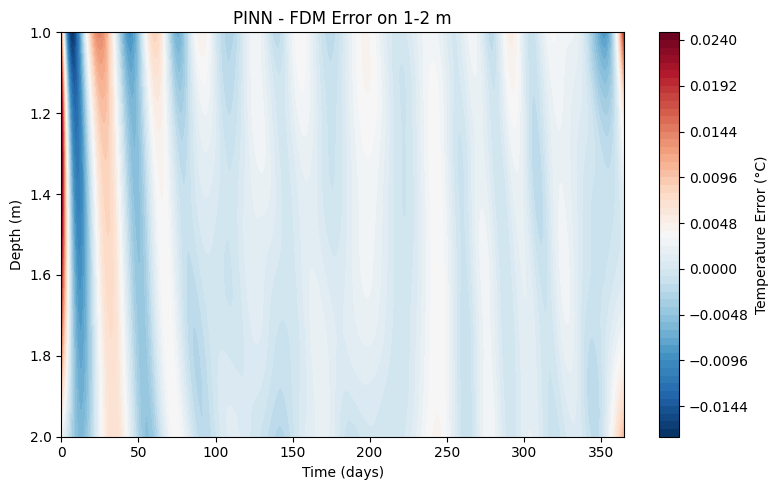


Final estimated parameters (1-2 m inversion):
eta_true        = 0.3
eta_inv         = 0.30697089433670044
lambda_f_true   = 0.1296
lambda_f_inv    = 0.1342049539089203
k_true          = 0.1
k_inv           = 0.09965731203556061
C_f_true        = 2.0
C_f_inv         = 2.0598275661468506


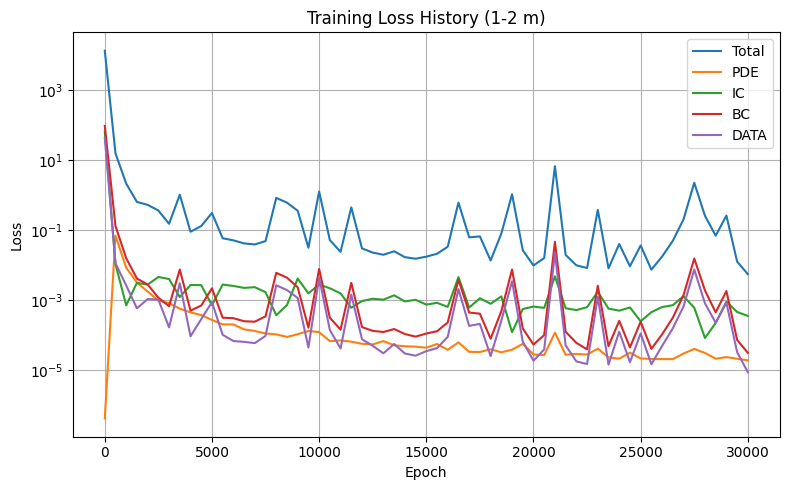

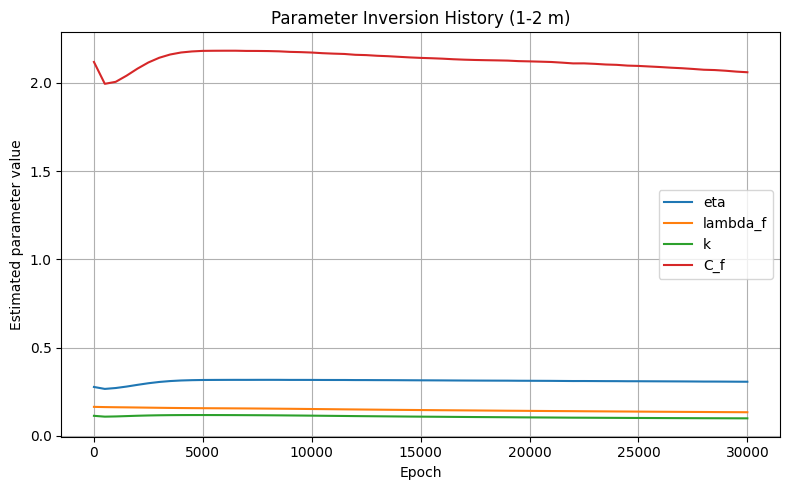

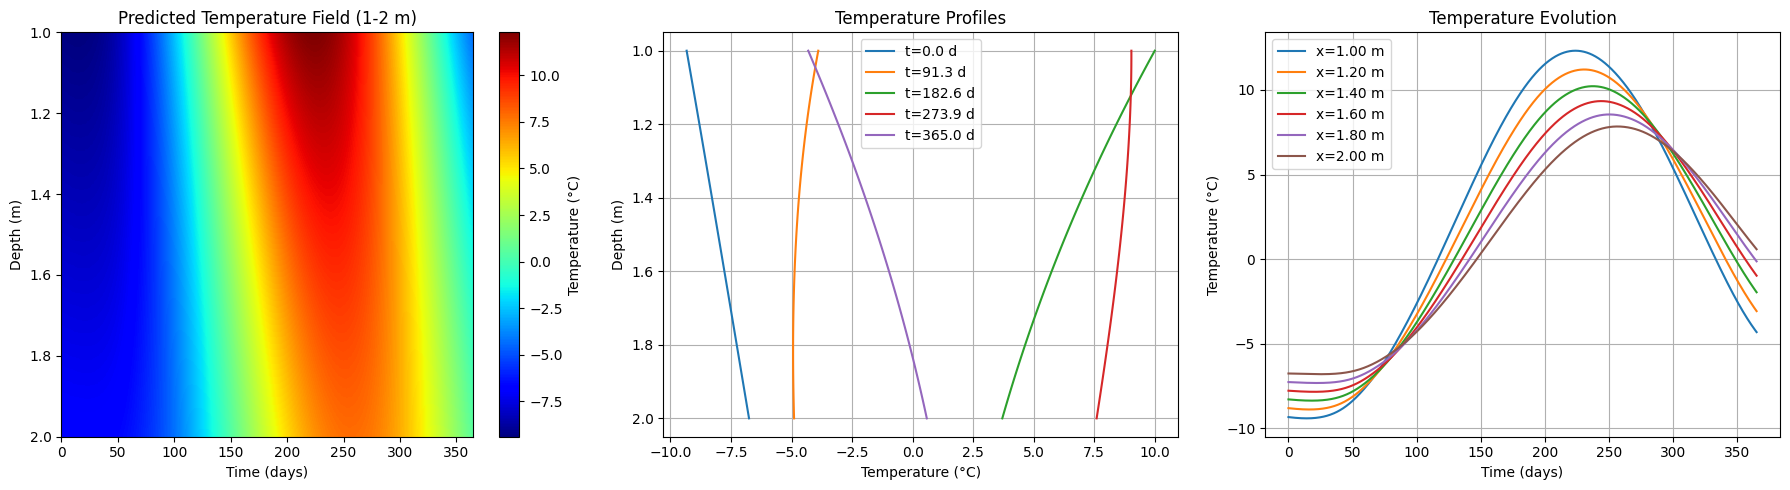

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# Inverse PINN model for 1-2 m inversion
# =========================================================
class FreezingSoilInversePINN:
    def __init__(self, params, device=None):
        # fixed physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']

        self.theta_r = params['theta_r']
        self.T_f = params['T_f']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        self.Lx = None
        self.T_total = None
        self.x_scale = None
        self.t_scale = None

        # actual depth offset for subdomain
        self.x_offset = 0.0

        # true values of inversion parameters
        self.eta_true = params['eta_true']
        self.lambda_f_true = params['lambda_f_true']
        self.k_true = params['k_true']
        self.C_f_true = params['C_f_true']

        # inversion switches
        self.invert_eta = params.get("invert_eta", True)
        self.invert_lambda_f = params.get("invert_lambda_f", True)
        self.invert_k = params.get("invert_k", False)
        self.invert_C_f = params.get("invert_C_f", False)

        # bounded ranges
        self.eta_min = 0.7 * self.eta_true
        self.eta_max = 1.3 * self.eta_true

        self.lambda_f_min = 0.7 * self.lambda_f_true
        self.lambda_f_max = 1.3 * self.lambda_f_true

        self.k_min = 0.7 * self.k_true
        self.k_max = 1.3 * self.k_true

        self.C_f_min = 0.7 * self.C_f_true
        self.C_f_max = 1.3 * self.C_f_true

        # random initialization
        eta_init = np.random.uniform(self.eta_min, self.eta_max)
        lambda_f_init = np.random.uniform(self.lambda_f_min, self.lambda_f_max)
        k_init = np.random.uniform(self.k_min, self.k_max)
        C_f_init = np.random.uniform(self.C_f_min, self.C_f_max)

        print(f"Random initial eta      = {eta_init:.8f}")
        print(f"Random initial lambda_f = {lambda_f_init:.8f}")
        print(f"Random initial k        = {k_init:.8f}")
        print(f"Random initial C_f      = {C_f_init:.8f}")

        def inverse_bounded_sigmoid(p_init, p_min, p_max):
            z = (p_init - p_min) / (p_max - p_min)
            z = np.clip(z, 1e-6, 1.0 - 1e-6)
            return np.log(z / (1.0 - z))

        self.eta_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(eta_init, self.eta_min, self.eta_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_eta
        )
        self.lambda_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(lambda_f_init, self.lambda_f_min, self.lambda_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_lambda_f
        )
        self.k_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(k_init, self.k_min, self.k_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_k
        )
        self.C_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(C_f_init, self.C_f_min, self.C_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_C_f
        )

        self.loss_history = []

        self.x_data = None
        self.t_data = None
        self.T_data = None

        self.t_bc = None
        self.T_left_bc = None
        self.T_right_bc = None

    @property
    def eta(self):
        return self.eta_min + (self.eta_max - self.eta_min) * torch.sigmoid(self.eta_raw)

    @property
    def lambda_f(self):
        return self.lambda_f_min + (self.lambda_f_max - self.lambda_f_min) * torch.sigmoid(self.lambda_f_raw)

    @property
    def k(self):
        return self.k_min + (self.k_max - self.k_min) * torch.sigmoid(self.k_raw)

    @property
    def C_f(self):
        return self.C_f_min + (self.C_f_max - self.C_f_min) * torch.sigmoid(self.C_f_raw)

    # =========================================================
    # Initial condition on subdomain
    # =========================================================
    def initial_temperature_profile_np(self, x_local):
        T_surface0 = 4.03 + 16.11 * np.sin(2.0 * np.pi * 0.0 / 365.0 - 1.709)
        T_bottom = 1.0
        x_actual = x_local + self.x_offset
        return T_surface0 + (T_bottom - T_surface0) * x_actual / 5.0

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def add_boundary_data(self, t_bc, T_left_bc, T_right_bc):
        self.t_bc = np.asarray(t_bc).reshape(-1)
        self.T_left_bc = np.asarray(T_left_bc).reshape(-1)
        self.T_right_bc = np.asarray(T_right_bc).reshape(-1)

    def sample_boundary(self, N_b):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set. Call add_boundary_data() first.")

        t = np.random.rand(N_b, 1) * self.T_total
        t_flat = t.reshape(-1)

        x_left = np.zeros((N_b, 1))
        T_left = np.interp(t_flat, self.t_bc, self.T_left_bc).reshape(-1, 1)

        x_right = np.ones((N_b, 1)) * self.Lx
        T_right = np.interp(t_flat, self.t_bc, self.T_right_bc).reshape(-1, 1)

        return (
            torch.tensor(x_left, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T_left, dtype=torch.float32, device=self.device),
            torch.tensor(x_right, dtype=torch.float32, device=self.device),
            torch.tensor(T_right, dtype=torch.float32, device=self.device),
        )

    # =========================================================
    # Observation data
    # =========================================================
    def add_temperature_observations(self, x_obs, t_obs, T_obs):
        self.x_data = torch.tensor(x_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.t_data = torch.tensor(t_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.T_data = torch.tensor(T_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)

    # =========================================================
    # Loss function
    # =========================================================
    def loss_function(self, N_f, N_i, N_b, w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0):
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        x_i, t_i, T_i = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i) ** 2)

        x_left, t_b, T_left, x_right, T_right = self.sample_boundary(N_b)
        T_left_pred = self.net_T(x_left, t_b)
        T_right_pred = self.net_T(x_right, t_b)

        loss_bc_left = torch.mean((T_left_pred - T_left) ** 2)
        loss_bc_right = torch.mean((T_right_pred - T_right) ** 2)
        loss_bc = loss_bc_left + loss_bc_right

        if self.x_data is not None:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)
        else:
            loss_data = torch.tensor(0.0, device=self.device)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        return total_loss, loss_pde, loss_ic, loss_bc, loss_data

    # =========================================================
    # Training
    # =========================================================
    def train(
        self,
        Lx,
        T_total,
        x_offset=1.0,
        epochs_adam=30000,
        lr=1e-3,
        N_f=4000,
        N_i=500,
        N_b=500,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total
        self.x_offset = x_offset

        params_to_optimize = list(self.model.parameters())
        if self.invert_eta:
            params_to_optimize.append(self.eta_raw)
        if self.invert_lambda_f:
            params_to_optimize.append(self.lambda_f_raw)
        if self.invert_k:
            params_to_optimize.append(self.k_raw)
        if self.invert_C_f:
            params_to_optimize.append(self.C_f_raw)

        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        start_time = time.time()

        for epoch in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                eta_val = self.eta.item()
                lambda_f_val = self.lambda_f.item()
                k_val = self.k.item()
                C_f_val = self.C_f.item()

                self.loss_history.append([
                    epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    eta_val,
                    lambda_f_val,
                    k_val,
                    C_f_val
                ])

                elapsed = time.time() - start_time
                print(
                    f"Epoch {epoch:6d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"PDE={loss_pde.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"eta={eta_val:.6f} | "
                    f"lambda_f={lambda_f_val:.6f} | "
                    f"k={k_val:.6f} | "
                    f"C_f={C_f_val:.6f} | "
                    f"time={elapsed:.1f}s"
                )

        if use_lbfgs:
            print("\nStarting L-BFGS optimization ...")

            optimizer_lbfgs = torch.optim.LBFGS(
                params_to_optimize,
                lr=1.0,
                max_iter=1000,
                max_eval=1200,
                history_size=50,
                tolerance_grad=1e-9,
                tolerance_change=1e-11,
                line_search_fn="strong_wolfe"
            )

            iteration_counter = [0]

            def closure():
                optimizer_lbfgs.zero_grad()

                total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )

                total_loss.backward()

                iteration_counter[0] += 1
                if iteration_counter[0] % 50 == 0:
                    eta_val = self.eta.item()
                    lambda_f_val = self.lambda_f.item()
                    k_val = self.k.item()
                    C_f_val = self.C_f.item()

                    self.loss_history.append([
                        epochs_adam + iteration_counter[0],
                        total_loss.item(),
                        loss_pde.item(),
                        loss_ic.item(),
                        loss_bc.item(),
                        loss_data.item(),
                        eta_val,
                        lambda_f_val,
                        k_val,
                        C_f_val
                    ])

                    print(
                        f"[LBFGS {iteration_counter[0]:5d}] "
                        f"Total={total_loss.item():.6e} | "
                        f"PDE={loss_pde.item():.6e} | "
                        f"IC={loss_ic.item():.6e} | "
                        f"BC={loss_bc.item():.6e} | "
                        f"DATA={loss_data.item():.6e} | "
                        f"eta={eta_val:.6f} | "
                        f"lambda_f={lambda_f_val:.6f} | "
                        f"k={k_val:.6f} | "
                        f"C_f={C_f_val:.6f}"
                    )

                return total_loss

            optimizer_lbfgs.step(closure)

        print("\nTraining finished.")
        print(f"Estimated eta      = {self.eta.item():.8f}")
        print(f"Estimated lambda_f = {self.lambda_f.item():.8f}")
        print(f"Estimated k        = {self.k.item():.8f}")
        print(f"Estimated C_f      = {self.C_f.item():.8f}")

    # =========================================================
    # Prediction
    # =========================================================
    def predict_field(self, Nx=101, Nt=1500):
        x_local = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        XX, TT = np.meshgrid(x_local, t, indexing='ij')

        x_in = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=self.device)
        t_in = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            T_pred = self.net_T(x_in, t_in).cpu().numpy().reshape(Nx, Nt)

        x_actual = x_local + self.x_offset
        return x_local, x_actual, t, T_pred

    # =========================================================
    # Plot
    # =========================================================
    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(8, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History (1-2 m)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hist[:, 0], hist[:, 6], label='eta')
        plt.plot(hist[:, 0], hist[:, 7], label='lambda_f')
        plt.plot(hist[:, 0], hist[:, 8], label='k')
        plt.plot(hist[:, 0], hist[:, 9], label='C_f')
        plt.xlabel("Epoch")
        plt.ylabel("Estimated parameter value")
        plt.title("Parameter Inversion History (1-2 m)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_results(self, Nx=101, Nt=1500):
        x_local, x_actual, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].imshow(
            T_field,
            extent=[t.min(), t.max(), x_actual.max(), x_actual.min()],
            aspect='auto',
            cmap='jet'
        )
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Predicted Temperature Field (1-2 m)')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        t_indices = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]
        for idx in t_indices:
            axes[1].plot(T_field[:, idx], x_actual, label=f't={t[idx]:.1f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x_actual - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x_actual[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Helper: build 1-2 m inversion data from three-layer FDM file
# =========================================================
def load_inverse_data_from_three_layer_fdm_1_2m(npz_file):
    data = np.load(npz_file)

    x_cascade = data["x"]
    t_cascade = data["t"]
    T_cascade = data["T_cascade"]

    # boundary data for 1-2 m
    idx_left = np.argmin(np.abs(x_cascade - 1.0))
    idx_right = np.argmin(np.abs(x_cascade - 2.0))

    T_left_bc = T_cascade[idx_left, :]
    T_right_bc = T_cascade[idx_right, :]

    # internal observation depths every 0.2 m in (1,2)
    internal_depths_actual = [1.2, 1.4, 1.6, 1.8]

    x_obs_local_list = []
    t_obs_list = []
    T_obs_list = []

    for depth_actual in internal_depths_actual:
        idx = np.argmin(np.abs(x_cascade - depth_actual))
        x_actual = x_cascade[idx]
        x_local = x_actual - 1.0

        for j, tt in enumerate(t_cascade):
            x_obs_local_list.append(x_local)
            t_obs_list.append(tt)
            T_obs_list.append(T_cascade[idx, j])

    x_obs_local = np.array(x_obs_local_list).reshape(-1, 1)
    t_obs = np.array(t_obs_list).reshape(-1, 1)
    T_obs = np.array(T_obs_list).reshape(-1, 1)

    return x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs_local, t_obs, T_obs


# =========================================================
# Compare prediction against FDM on 1-2 m
# =========================================================
def compare_with_fdm_1_2m(x_actual_pred, t_pred, T_pred, x_cascade, t_cascade, T_cascade):
    mask = (x_cascade >= 1.0 - 1e-12) & (x_cascade <= 2.0 + 1e-12)
    x_ref = x_cascade[mask]
    T_ref = T_cascade[mask, :]

    if not (len(x_actual_pred) == len(x_ref) and np.allclose(x_actual_pred, x_ref) and
            len(t_pred) == len(t_cascade) and np.allclose(t_pred, t_cascade)):
        T_tmp = np.zeros((T_pred.shape[0], len(t_cascade)))
        for i in range(T_pred.shape[0]):
            T_tmp[i, :] = np.interp(t_cascade, t_pred, T_pred[i, :])

        T_pred_interp = np.zeros((len(x_ref), len(t_cascade)))
        for j in range(len(t_cascade)):
            T_pred_interp[:, j] = np.interp(x_ref, x_actual_pred, T_tmp[:, j])
    else:
        T_pred_interp = T_pred

    error = T_pred_interp - T_ref
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    max_abs = np.max(np.abs(error))

    print("\n===== 1-2 m inversion vs FDM =====")
    print(f"MAE      = {mae:.6e}")
    print(f"RMSE     = {rmse:.6e}")
    print(f"Max |err|= {max_abs:.6e}")

    plt.figure(figsize=(8, 5))
    im = plt.contourf(t_cascade, x_ref, error, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("PINN - FDM Error on 1-2 m")
    plt.colorbar(im, label="Temperature Error (°C)")
    plt.tight_layout()
    plt.show()

    return mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp


# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    set_random_seed(42)

    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,

        # true values for layer 2
        'eta_true': 0.30,
        'lambda_f_true': 1.500e-6 * 8.64e4,
        'k_true': 0.10,
        'C_f_true': 2.00,

        'theta_r': 0.10,
        'T_f': -0.3,

        # recommend starting with 2-parameter inversion
        'invert_eta': True,
        'invert_lambda_f': True,
        'invert_k': True,
        'invert_C_f': True
    }

    pinn = FreezingSoilInversePINN(params)

    x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs, t_obs, T_obs = \
        load_inverse_data_from_three_layer_fdm_1_2m("fdm_three_layer_cascade_result.npz")

    pinn.add_boundary_data(t_cascade, T_left_bc, T_right_bc)
    pinn.add_temperature_observations(x_obs, t_obs, T_obs)

    print("Observation points loaded:", len(T_obs))
    print("Boundary data loaded from x=1 m and x=2 m.")
    print("True eta value         =", params['eta_true'])
    print("True lambda_f value    =", params['lambda_f_true'])
    print("True k value           =", params['k_true'])
    print("True C_f value         =", params['C_f_true'])
    print("Initial eta guess      =", pinn.eta.item())
    print("Initial lambda_f guess =", pinn.lambda_f.item())
    print("Initial k guess        =", pinn.k.item())
    print("Initial C_f guess      =", pinn.C_f.item())

    pinn.train(
        Lx=1.0,
        T_total=365.0,
        x_offset=1.0,
        epochs_adam=30000,
        lr=1e-3,
        N_f=4000,
        N_i=500,
        N_b=500,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    )

    x_local_pinn, x_actual_pinn, t_pinn, T_field_pinn = pinn.predict_field(Nx=101, Nt=1500)

    mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp = compare_with_fdm_1_2m(
        x_actual_pinn, t_pinn, T_field_pinn, x_cascade, t_cascade, T_cascade
    )

    np.savez(
        "inverse_pinn_1_2m_result.npz",
        x_local_pinn=x_local_pinn,
        x_actual_pinn=x_actual_pinn,
        t_pinn=t_pinn,
        T_field_pinn=T_field_pinn,
        eta_inv=pinn.eta.item(),
        lambda_f_inv=pinn.lambda_f.item(),
        k_inv=pinn.k.item(),
        C_f_inv=pinn.C_f.item(),
        mae=mae,
        rmse=rmse,
        max_abs=max_abs
    )

    np.savetxt(
        "inverse_pinn_1_2m_loss_history.csv",
        np.array(pinn.loss_history),
        delimiter=",",
        header="epoch,total_loss,pde_loss,ic_loss,bc_loss,data_loss,eta,lambda_f,k,C_f",
        comments=""
    )

    print("\nFinal estimated parameters (1-2 m inversion):")
    print("eta_true        =", params['eta_true'])
    print("eta_inv         =", pinn.eta.item())
    print("lambda_f_true   =", params['lambda_f_true'])
    print("lambda_f_inv    =", pinn.lambda_f.item())
    print("k_true          =", params['k_true'])
    print("k_inv           =", pinn.k.item())
    print("C_f_true        =", params['C_f_true'])
    print("C_f_inv         =", pinn.C_f.item())

    pinn.plot_loss()
    pinn.plot_results(Nx=101, Nt=1500)

## 1.3 Third-layer inversion

Random initial eta      = 0.27741722
Random initial lambda_f = 0.27441257
Random initial k        = 0.11391964
Random initial C_f      = 1.69471214
Observation points loaded: 56000
Boundary data loaded from x=2 m and x=5 m.
True eta value         = 0.3
True lambda_f value    = 0.21600000000000003
True k value           = 0.1
True C_f value         = 1.6
Initial eta guess      = 0.27741721272468567
Initial lambda_f guess = 0.2744125723838806
Initial k guess        = 0.11391963064670563
Initial C_f guess      = 1.6947121620178223
Epoch      1 | Total=3.607442e+03 | PDE=1.739605e-06 | IC=1.342892e+01 | BC=2.976591e+01 | DATA=1.052858e+01 | eta=0.277375 | lambda_f=0.274419 | k=0.113908 | C_f=1.694481 | time=0.0s
Epoch    500 | Total=2.173342e+00 | PDE=1.094876e-03 | IC=1.487585e-03 | BC=1.504587e-02 | DATA=1.623424e-03 | eta=0.284067 | lambda_f=0.272438 | k=0.112218 | C_f=1.663401 | time=11.8s
Epoch   1000 | Total=7.472426e-01 | PDE=3.047929e-04 | IC=9.395382e-04 | BC=6.539476e-03 | DATA=5

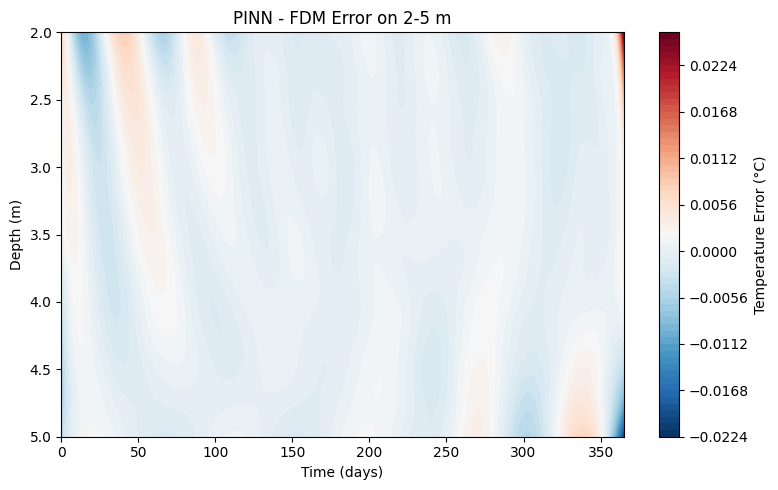


Final estimated parameters (2-5 m inversion):
eta_true        = 0.3
eta_inv         = 0.31750309467315674
lambda_f_true   = 0.21600000000000003
lambda_f_inv    = 0.23820923268795013
k_true          = 0.1
k_inv           = 0.1053076684474945
C_f_true        = 1.6
C_f_inv         = 1.6303143501281738


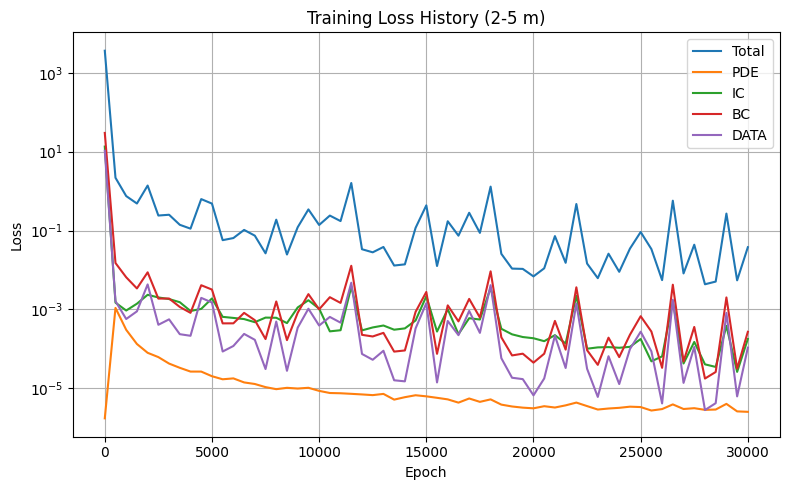

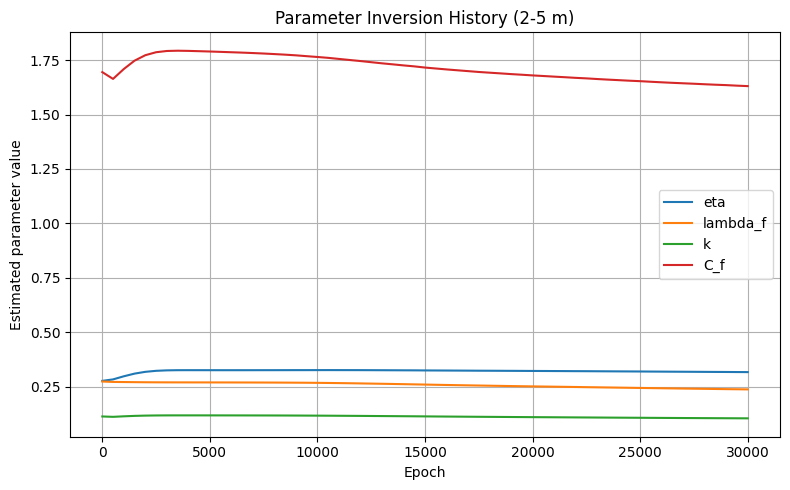

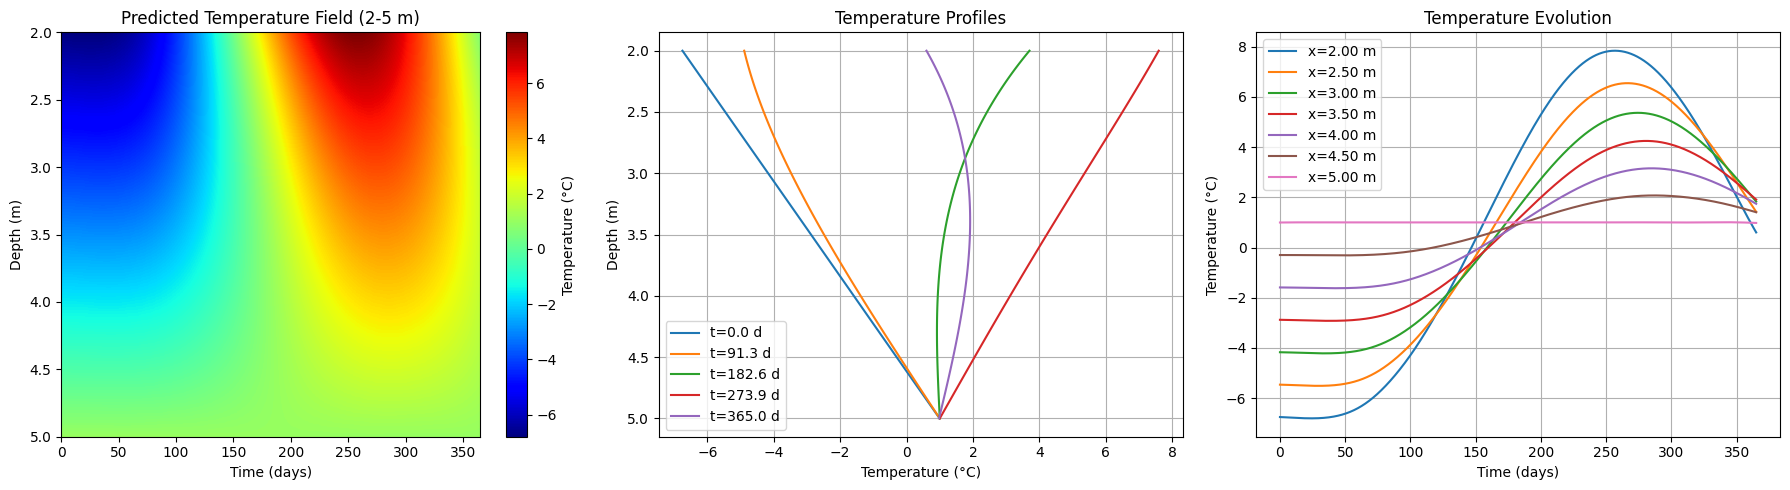

In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# Inverse PINN model for 2-5 m inversion
# =========================================================
class FreezingSoilInversePINN:
    def __init__(self, params, device=None):
        # fixed physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']

        self.theta_r = params['theta_r']
        self.T_f = params['T_f']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        self.Lx = None
        self.T_total = None
        self.x_scale = None
        self.t_scale = None

        # actual depth offset for subdomain
        self.x_offset = 0.0

        # true values of inversion parameters
        self.eta_true = params['eta_true']
        self.lambda_f_true = params['lambda_f_true']
        self.k_true = params['k_true']
        self.C_f_true = params['C_f_true']

        # inversion switches
        self.invert_eta = params.get("invert_eta", True)
        self.invert_lambda_f = params.get("invert_lambda_f", True)
        self.invert_k = params.get("invert_k", False)
        self.invert_C_f = params.get("invert_C_f", False)

        # bounded ranges
        self.eta_min = 0.7 * self.eta_true
        self.eta_max = 1.3 * self.eta_true

        self.lambda_f_min = 0.7 * self.lambda_f_true
        self.lambda_f_max = 1.3 * self.lambda_f_true

        self.k_min = 0.7 * self.k_true
        self.k_max = 1.3 * self.k_true

        self.C_f_min = 0.7 * self.C_f_true
        self.C_f_max = 1.3 * self.C_f_true

        # random initialization
        eta_init = np.random.uniform(self.eta_min, self.eta_max)
        lambda_f_init = np.random.uniform(self.lambda_f_min, self.lambda_f_max)
        k_init = np.random.uniform(self.k_min, self.k_max)
        C_f_init = np.random.uniform(self.C_f_min, self.C_f_max)

        print(f"Random initial eta      = {eta_init:.8f}")
        print(f"Random initial lambda_f = {lambda_f_init:.8f}")
        print(f"Random initial k        = {k_init:.8f}")
        print(f"Random initial C_f      = {C_f_init:.8f}")

        def inverse_bounded_sigmoid(p_init, p_min, p_max):
            z = (p_init - p_min) / (p_max - p_min)
            z = np.clip(z, 1e-6, 1.0 - 1e-6)
            return np.log(z / (1.0 - z))

        self.eta_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(eta_init, self.eta_min, self.eta_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_eta
        )
        self.lambda_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(lambda_f_init, self.lambda_f_min, self.lambda_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_lambda_f
        )
        self.k_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(k_init, self.k_min, self.k_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_k
        )
        self.C_f_raw = nn.Parameter(
            torch.tensor([inverse_bounded_sigmoid(C_f_init, self.C_f_min, self.C_f_max)],
                         dtype=torch.float32, device=self.device),
            requires_grad=self.invert_C_f
        )

        self.loss_history = []

        self.x_data = None
        self.t_data = None
        self.T_data = None

        self.t_bc = None
        self.T_left_bc = None
        self.T_right_bc = None

    @property
    def eta(self):
        return self.eta_min + (self.eta_max - self.eta_min) * torch.sigmoid(self.eta_raw)

    @property
    def lambda_f(self):
        return self.lambda_f_min + (self.lambda_f_max - self.lambda_f_min) * torch.sigmoid(self.lambda_f_raw)

    @property
    def k(self):
        return self.k_min + (self.k_max - self.k_min) * torch.sigmoid(self.k_raw)

    @property
    def C_f(self):
        return self.C_f_min + (self.C_f_max - self.C_f_min) * torch.sigmoid(self.C_f_raw)

    # =========================================================
    # Initial condition on subdomain
    # =========================================================
    def initial_temperature_profile_np(self, x_local):
        T_surface0 = 4.03 + 16.11 * np.sin(2.0 * np.pi * 0.0 / 365.0 - 1.709)
        T_bottom = 1.0
        x_actual = x_local + self.x_offset
        return T_surface0 + (T_bottom - T_surface0) * x_actual / 5.0

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def add_boundary_data(self, t_bc, T_left_bc, T_right_bc):
        self.t_bc = np.asarray(t_bc).reshape(-1)
        self.T_left_bc = np.asarray(T_left_bc).reshape(-1)
        self.T_right_bc = np.asarray(T_right_bc).reshape(-1)

    def sample_boundary(self, N_b):
        if self.t_bc is None:
            raise RuntimeError("Boundary data not set. Call add_boundary_data() first.")

        t = np.random.rand(N_b, 1) * self.T_total
        t_flat = t.reshape(-1)

        x_left = np.zeros((N_b, 1))
        T_left = np.interp(t_flat, self.t_bc, self.T_left_bc).reshape(-1, 1)

        x_right = np.ones((N_b, 1)) * self.Lx
        T_right = np.interp(t_flat, self.t_bc, self.T_right_bc).reshape(-1, 1)

        return (
            torch.tensor(x_left, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T_left, dtype=torch.float32, device=self.device),
            torch.tensor(x_right, dtype=torch.float32, device=self.device),
            torch.tensor(T_right, dtype=torch.float32, device=self.device),
        )

    # =========================================================
    # Observation data
    # =========================================================
    def add_temperature_observations(self, x_obs, t_obs, T_obs):
        self.x_data = torch.tensor(x_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.t_data = torch.tensor(t_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.T_data = torch.tensor(T_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)

    # =========================================================
    # Loss function
    # =========================================================
    def loss_function(self, N_f, N_i, N_b, w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0):
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        x_i, t_i, T_i = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i) ** 2)

        x_left, t_b, T_left, x_right, T_right = self.sample_boundary(N_b)
        T_left_pred = self.net_T(x_left, t_b)
        T_right_pred = self.net_T(x_right, t_b)

        loss_bc_left = torch.mean((T_left_pred - T_left) ** 2)
        loss_bc_right = torch.mean((T_right_pred - T_right) ** 2)
        loss_bc = loss_bc_left + loss_bc_right

        if self.x_data is not None:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)
        else:
            loss_data = torch.tensor(0.0, device=self.device)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        return total_loss, loss_pde, loss_ic, loss_bc, loss_data

    # =========================================================
    # Training
    # =========================================================
    def train(
        self,
        Lx,
        T_total,
        x_offset=2.0,
        epochs_adam=30000,
        lr=1e-3,
        N_f=6000,
        N_i=800,
        N_b=800,
        w_pde=1000.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total
        self.x_offset = x_offset

        params_to_optimize = list(self.model.parameters())
        if self.invert_eta:
            params_to_optimize.append(self.eta_raw)
        if self.invert_lambda_f:
            params_to_optimize.append(self.lambda_f_raw)
        if self.invert_k:
            params_to_optimize.append(self.k_raw)
        if self.invert_C_f:
            params_to_optimize.append(self.C_f_raw)

        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        start_time = time.time()

        for epoch in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                eta_val = self.eta.item()
                lambda_f_val = self.lambda_f.item()
                k_val = self.k.item()
                C_f_val = self.C_f.item()

                self.loss_history.append([
                    epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    eta_val,
                    lambda_f_val,
                    k_val,
                    C_f_val
                ])

                elapsed = time.time() - start_time
                print(
                    f"Epoch {epoch:6d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"PDE={loss_pde.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"eta={eta_val:.6f} | "
                    f"lambda_f={lambda_f_val:.6f} | "
                    f"k={k_val:.6f} | "
                    f"C_f={C_f_val:.6f} | "
                    f"time={elapsed:.1f}s"
                )

        if use_lbfgs:
            print("\nStarting L-BFGS optimization ...")

            optimizer_lbfgs = torch.optim.LBFGS(
                params_to_optimize,
                lr=1.0,
                max_iter=1000,
                max_eval=1200,
                history_size=50,
                tolerance_grad=1e-9,
                tolerance_change=1e-11,
                line_search_fn="strong_wolfe"
            )

            iteration_counter = [0]

            def closure():
                optimizer_lbfgs.zero_grad()

                total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )

                total_loss.backward()

                iteration_counter[0] += 1
                if iteration_counter[0] % 50 == 0:
                    eta_val = self.eta.item()
                    lambda_f_val = self.lambda_f.item()
                    k_val = self.k.item()
                    C_f_val = self.C_f.item()

                    self.loss_history.append([
                        epochs_adam + iteration_counter[0],
                        total_loss.item(),
                        loss_pde.item(),
                        loss_ic.item(),
                        loss_bc.item(),
                        loss_data.item(),
                        eta_val,
                        lambda_f_val,
                        k_val,
                        C_f_val
                    ])

                    print(
                        f"[LBFGS {iteration_counter[0]:5d}] "
                        f"Total={total_loss.item():.6e} | "
                        f"PDE={loss_pde.item():.6e} | "
                        f"IC={loss_ic.item():.6e} | "
                        f"BC={loss_bc.item():.6e} | "
                        f"DATA={loss_data.item():.6e} | "
                        f"eta={eta_val:.6f} | "
                        f"lambda_f={lambda_f_val:.6f} | "
                        f"k={k_val:.6f} | "
                        f"C_f={C_f_val:.6f}"
                    )

                return total_loss

            optimizer_lbfgs.step(closure)

        print("\nTraining finished.")
        print(f"Estimated eta      = {self.eta.item():.8f}")
        print(f"Estimated lambda_f = {self.lambda_f.item():.8f}")
        print(f"Estimated k        = {self.k.item():.8f}")
        print(f"Estimated C_f      = {self.C_f.item():.8f}")

    # =========================================================
    # Prediction
    # =========================================================
    def predict_field(self, Nx=121, Nt=1500):
        x_local = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        XX, TT = np.meshgrid(x_local, t, indexing='ij')

        x_in = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=self.device)
        t_in = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            T_pred = self.net_T(x_in, t_in).cpu().numpy().reshape(Nx, Nt)

        x_actual = x_local + self.x_offset
        return x_local, x_actual, t, T_pred

    # =========================================================
    # Plot
    # =========================================================
    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(8, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History (2-5 m)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hist[:, 0], hist[:, 6], label='eta')
        plt.plot(hist[:, 0], hist[:, 7], label='lambda_f')
        plt.plot(hist[:, 0], hist[:, 8], label='k')
        plt.plot(hist[:, 0], hist[:, 9], label='C_f')
        plt.xlabel("Epoch")
        plt.ylabel("Estimated parameter value")
        plt.title("Parameter Inversion History (2-5 m)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_results(self, Nx=121, Nt=1500):
        x_local, x_actual, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].imshow(
            T_field,
            extent=[t.min(), t.max(), x_actual.max(), x_actual.min()],
            aspect='auto',
            cmap='jet'
        )
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Predicted Temperature Field (2-5 m)')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        t_indices = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]
        for idx in t_indices:
            axes[1].plot(T_field[:, idx], x_actual, label=f't={t[idx]:.1f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x_actual - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x_actual[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Helper: build 2-5 m inversion data from three-layer FDM file
# =========================================================
def load_inverse_data_from_three_layer_fdm_2_5m(npz_file):
    data = np.load(npz_file)

    x_cascade = data["x"]
    t_cascade = data["t"]
    T_cascade = data["T_cascade"]

    # boundary data for 2-5 m
    idx_left = np.argmin(np.abs(x_cascade - 2.0))
    idx_right = np.argmin(np.abs(x_cascade - 5.0))

    T_left_bc = T_cascade[idx_left, :]
    T_right_bc = T_cascade[idx_right, :]

    # internal observation depths every 0.2 m in (2,5)
    internal_depths_actual = np.arange(2.2, 5.0, 0.2)

    x_obs_local_list = []
    t_obs_list = []
    T_obs_list = []

    for depth_actual in internal_depths_actual:
        idx = np.argmin(np.abs(x_cascade - depth_actual))
        x_actual = x_cascade[idx]
        x_local = x_actual - 2.0

        for j, tt in enumerate(t_cascade):
            x_obs_local_list.append(x_local)
            t_obs_list.append(tt)
            T_obs_list.append(T_cascade[idx, j])

    x_obs_local = np.array(x_obs_local_list).reshape(-1, 1)
    t_obs = np.array(t_obs_list).reshape(-1, 1)
    T_obs = np.array(T_obs_list).reshape(-1, 1)

    return x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs_local, t_obs, T_obs


# =========================================================
# Compare prediction against FDM on 2-5 m
# =========================================================
def compare_with_fdm_2_5m(x_actual_pred, t_pred, T_pred, x_cascade, t_cascade, T_cascade):
    mask = (x_cascade >= 2.0 - 1e-12) & (x_cascade <= 5.0 + 1e-12)
    x_ref = x_cascade[mask]
    T_ref = T_cascade[mask, :]

    if not (len(x_actual_pred) == len(x_ref) and np.allclose(x_actual_pred, x_ref) and
            len(t_pred) == len(t_cascade) and np.allclose(t_pred, t_cascade)):
        T_tmp = np.zeros((T_pred.shape[0], len(t_cascade)))
        for i in range(T_pred.shape[0]):
            T_tmp[i, :] = np.interp(t_cascade, t_pred, T_pred[i, :])

        T_pred_interp = np.zeros((len(x_ref), len(t_cascade)))
        for j in range(len(t_cascade)):
            T_pred_interp[:, j] = np.interp(x_ref, x_actual_pred, T_tmp[:, j])
    else:
        T_pred_interp = T_pred

    error = T_pred_interp - T_ref
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    max_abs = np.max(np.abs(error))

    print("\n===== 2-5 m inversion vs FDM =====")
    print(f"MAE      = {mae:.6e}")
    print(f"RMSE     = {rmse:.6e}")
    print(f"Max |err|= {max_abs:.6e}")

    plt.figure(figsize=(8, 5))
    im = plt.contourf(t_cascade, x_ref, error, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("PINN - FDM Error on 2-5 m")
    plt.colorbar(im, label="Temperature Error (°C)")
    plt.tight_layout()
    plt.show()

    return mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp


# =========================================================
# Main
# =========================================================
if __name__ == "__main__":
    set_random_seed(42)

    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,

        # true values for layer 3
        'eta_true': 0.30,
        'lambda_f_true': 2.500e-6 * 8.64e4,
        'k_true': 0.10,
        'C_f_true': 1.60,

        'theta_r': 0.10,
        'T_f': -0.3,

        # recommend starting with 2-parameter inversion
        'invert_eta': True,
        'invert_lambda_f': True,
        'invert_k': True,
        'invert_C_f': True
    }

    pinn = FreezingSoilInversePINN(params)

    x_cascade, t_cascade, T_cascade, T_left_bc, T_right_bc, x_obs, t_obs, T_obs = \
        load_inverse_data_from_three_layer_fdm_2_5m("fdm_three_layer_cascade_result.npz")

    pinn.add_boundary_data(t_cascade, T_left_bc, T_right_bc)
    pinn.add_temperature_observations(x_obs, t_obs, T_obs)

    print("Observation points loaded:", len(T_obs))
    print("Boundary data loaded from x=2 m and x=5 m.")
    print("True eta value         =", params['eta_true'])
    print("True lambda_f value    =", params['lambda_f_true'])
    print("True k value           =", params['k_true'])
    print("True C_f value         =", params['C_f_true'])
    print("Initial eta guess      =", pinn.eta.item())
    print("Initial lambda_f guess =", pinn.lambda_f.item())
    print("Initial k guess        =", pinn.k.item())
    print("Initial C_f guess      =", pinn.C_f.item())

    pinn.train(
        Lx=3.0,
        T_total=365.0,
        x_offset=2.0,
        epochs_adam=30000,
        lr=1e-3,
        N_f=6000,
        N_i=800,
        N_b=800,
        w_pde=1000.0,
        w_ic=1.0,
        w_bc=50.0,
        w_data=200.0,
        print_every=500,
        use_lbfgs=True
    )

    x_local_pinn, x_actual_pinn, t_pinn, T_field_pinn = pinn.predict_field(Nx=121, Nt=1500)

    mae, rmse, max_abs, error, x_ref, T_ref, T_pred_interp = compare_with_fdm_2_5m(
        x_actual_pinn, t_pinn, T_field_pinn, x_cascade, t_cascade, T_cascade
    )

    np.savez(
        "inverse_pinn_2_5m_result.npz",
        x_local_pinn=x_local_pinn,
        x_actual_pinn=x_actual_pinn,
        t_pinn=t_pinn,
        T_field_pinn=T_field_pinn,
        eta_inv=pinn.eta.item(),
        lambda_f_inv=pinn.lambda_f.item(),
        k_inv=pinn.k.item(),
        C_f_inv=pinn.C_f.item(),
        mae=mae,
        rmse=rmse,
        max_abs=max_abs
    )

    np.savetxt(
        "inverse_pinn_2_5m_loss_history.csv",
        np.array(pinn.loss_history),
        delimiter=",",
        header="epoch,total_loss,pde_loss,ic_loss,bc_loss,data_loss,eta,lambda_f,k,C_f",
        comments=""
    )

    print("\nFinal estimated parameters (2-5 m inversion):")
    print("eta_true        =", params['eta_true'])
    print("eta_inv         =", pinn.eta.item())
    print("lambda_f_true   =", params['lambda_f_true'])
    print("lambda_f_inv    =", pinn.lambda_f.item())
    print("k_true          =", params['k_true'])
    print("k_inv           =", pinn.k.item())
    print("C_f_true        =", params['C_f_true'])
    print("C_f_inv         =", pinn.C_f.item())

    pinn.plot_loss()
    pinn.plot_results(Nx=121, Nt=1500)